# N-Gram Analysis — Berita MBG
Analisis unigram, bigram, dan trigram dari korpus artikel berita MBG yang telah di-scrape.

## 1. Import & Load Data

In [2]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/ergia/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/ergia/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /home/ergia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv('scraped_articles.csv')
print(f'Total artikel: {len(df)}')
print(f'Artikel dengan konten: {df["content"].notna().sum()}')
df.head(2)

Total artikel: 755
Artikel dengan konten: 344


,url,title,content,error
0,https://tribratanews.polri.go.id/blog/nasional...,Wamendukbangga: Distribusi MBG untuk Ibu Hamil...,Tribratanews.polri.go.id– Jakarta. Wakil Mente...,NaN
1,https://www.tempo.co/kolom/mbg-dan-pertaruhan-...,Makan Gratis dan Pertaruhan Politik Anggaran |...,Iklan\nBerita Tempo Plus\nHandi Risza\nWakil R...,NaN


## 2. Preprocessing

In [4]:
# Gabungkan semua konten artikel menjadi satu korpus
corpus = ' '.join(df['content'].dropna().tolist())

# Lowercase
corpus = corpus.lower()

# Hapus karakter non-alfabet (angka, tanda baca, simbol)
corpus = re.sub(r'[^a-z\s]', ' ', corpus)

# Tokenisasi
tokens = word_tokenize(corpus)

print(f'Total token (sebelum hapus stopword): {len(tokens)}')

Total token (sebelum hapus stopword): 223048


In [5]:
# Hapus stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Tambahan stopword umum yang tidak informatif
extra_stopwords = {'yang', 'di', 'dan', 'ini', 'itu', 'dari', 'ke', 'untuk',
                   'dengan', 'pada', 'dalam', 'adalah', 'akan', 'juga', 'tidak',
                   'oleh', 'atau', 'sudah', 'saat', 'bisa', 'ada', 'lebih',
                   'telah', 'serta', 'dapat', 'para', 'agar', 'hal', 'setelah'}
stop_words.update(extra_stopwords)

tokens_filtered = [t for t in tokens if t not in stop_words and len(t) > 1]

print(f'Total token (setelah hapus stopword): {len(tokens_filtered)}')

Total token (setelah hapus stopword): 141473


## 3. Generate N-Grams

In [6]:
# Unigram
unigrams = list(ngrams(tokens_filtered, 1))
unigram_freq = Counter(unigrams)

# Bigram
bigrams = list(ngrams(tokens_filtered, 2))
bigram_freq = Counter(bigrams)

# Trigram
trigrams = list(ngrams(tokens_filtered, 3))
trigram_freq = Counter(trigrams)

print(f'Jumlah unigram unik : {len(unigram_freq)}')
print(f'Jumlah bigram unik  : {len(bigram_freq)}')
print(f'Jumlah trigram unik : {len(trigram_freq)}')

Jumlah unigram unik : 11568
Jumlah bigram unik  : 61945
Jumlah trigram unik : 83790


## 4. Top N-Grams

In [7]:
TOP_N = 20

top_unigrams = unigram_freq.most_common(TOP_N)
top_bigrams  = bigram_freq.most_common(TOP_N)
top_trigrams = trigram_freq.most_common(TOP_N)

print('=== Top Unigram ===')
for gram, freq in top_unigrams:
    print(f'  {", ".join(gram):<30} {freq}')

print('\n=== Top Bigram ===')
for gram, freq in top_bigrams:
    print(f'  {", ".join(gram):<40} {freq}')

print('\n=== Top Trigram ===')
for gram, freq in top_trigrams:
    print(f'  {", ".join(gram):<55} {freq}')

=== Top Unigram ===
  program                        2616
  mbg                            2004
  gizi                           1936
  makan                          1468
  sppg                           1367
  anak                           1344
  gratis                         1168
  makanan                        1161
  bergizi                        1093
  pemerintah                     1055
  nasional                       1010
  sekolah                        933
  badan                          845
  bgn                            765
  presiden                       746
  indonesia                      735
  pangan                         624
  anggaran                       611
  masyarakat                     609
  kesehatan                      607

=== Top Bigram ===
  bergizi, gratis                          801
  makan, bergizi                           755
  gizi, nasional                           681
  program, makan                           669
  badan, gizi        

## 5. Visualisasi

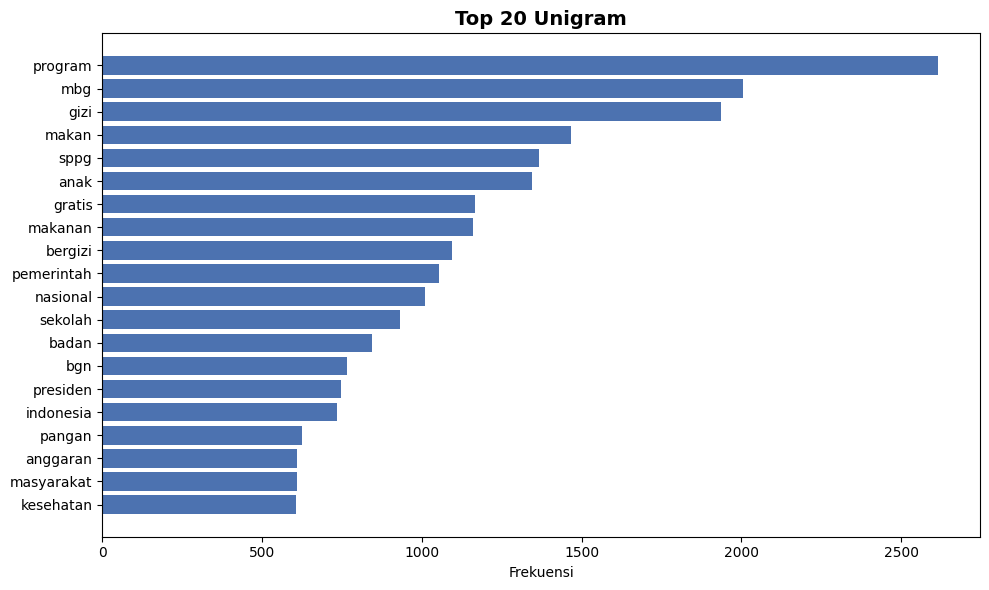

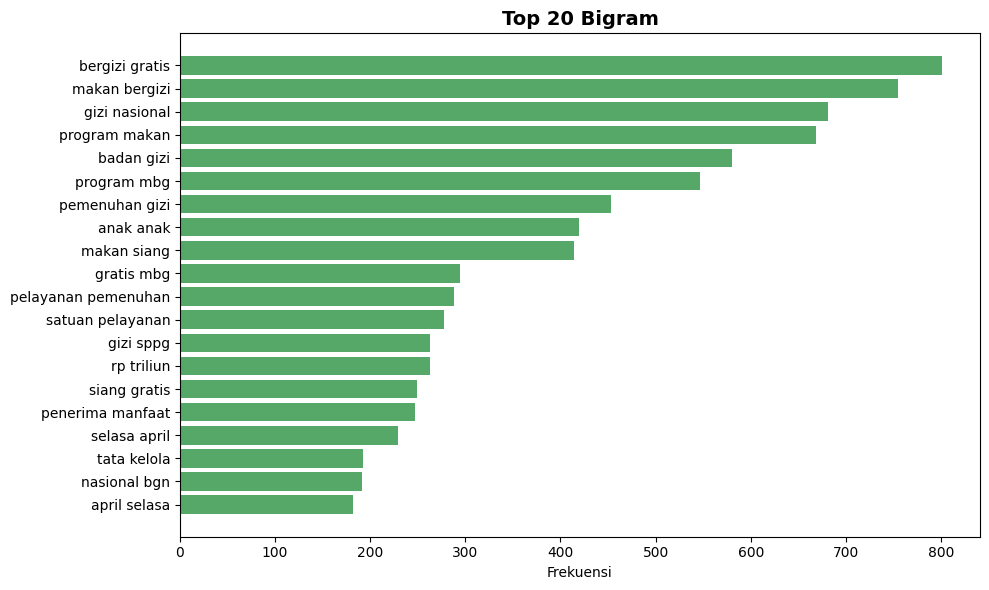

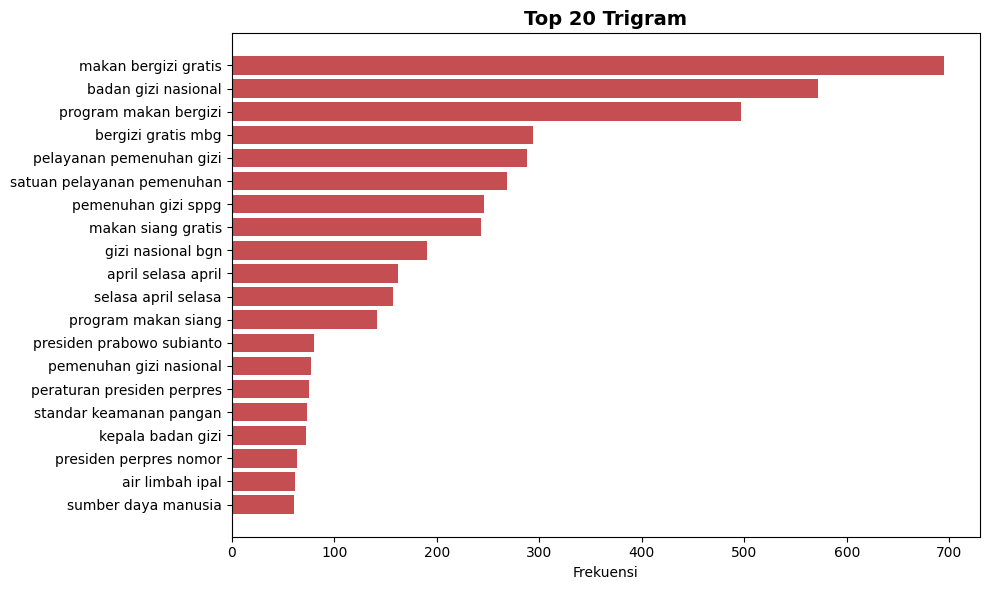

In [8]:
def plot_ngram(freq_list, title, color):
    labels = [' '.join(gram) for gram, _ in freq_list]
    values = [freq for _, freq in freq_list]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    plt.tight_layout()
    plt.show()

plot_ngram(top_unigrams, f'Top {TOP_N} Unigram', '#4C72B0')
plot_ngram(top_bigrams,  f'Top {TOP_N} Bigram',  '#55A868')
plot_ngram(top_trigrams, f'Top {TOP_N} Trigram', '#C44E52')

## 6. TF-IDF N-Gram Weighting
Berbeda dari frekuensi mentah, TF-IDF memberi bobot lebih tinggi pada n-gram yang sering muncul di suatu artikel tetapi jarang di artikel lain — sehingga lebih *distinctive*.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Gunakan konten per artikel (bukan corpus gabungan)
documents = df['content'].dropna().tolist()

# TF-IDF untuk unigram, bigram, dan trigram
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    stop_words=list(stop_words),
    max_features=5000,
    token_pattern=r'(?u)\b[a-z]{2,}\b'  # hanya kata dengan min 2 huruf
)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Jumlahkan skor TF-IDF tiap n-gram di seluruh dokumen
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1

tfidf_df = pd.DataFrame({'ngram': feature_names, 'tfidf_score': tfidf_scores})
tfidf_df['n'] = tfidf_df['ngram'].apply(lambda x: len(x.split()))
tfidf_df = tfidf_df.sort_values('tfidf_score', ascending=False)

# Pisah per jenis n-gram
top_tfidf_uni = tfidf_df[tfidf_df['n'] == 1].head(TOP_N)
top_tfidf_bi  = tfidf_df[tfidf_df['n'] == 2].head(TOP_N)
top_tfidf_tri = tfidf_df[tfidf_df['n'] == 3].head(TOP_N)

print('=== Top TF-IDF Unigram ===')
print(top_tfidf_uni[['ngram', 'tfidf_score']].to_string(index=False))
print('\n=== Top TF-IDF Bigram ===')
print(top_tfidf_bi[['ngram', 'tfidf_score']].to_string(index=False))
print('\n=== Top TF-IDF Trigram ===')
print(top_tfidf_tri[['ngram', 'tfidf_score']].to_string(index=False))


/home/ergia/Documents/codes/PBAKelompok1/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


=== Top TF-IDF Unigram ===
     ngram  tfidf_score
   program    21.890624
       mbg    21.140064
      sppg    17.652891
      gizi    16.988766
      anak    14.557109
       bgn    11.804225
     makan    11.547694
   makanan    10.903815
pemerintah    10.339556
   sekolah    10.307865
  nasional    10.285973
   bergizi     9.914900
  presiden     9.771944
     dapur     9.481301
     siswa     9.450279
     badan     9.414203
    gratis     9.182279
masyarakat     7.942945
 indonesia     7.844668
pendidikan     7.827644

=== Top TF-IDF Bigram ===
              ngram  tfidf_score
      gizi nasional     8.549366
      makan bergizi     7.811634
     bergizi gratis     7.653718
        program mbg     7.540189
         badan gizi     7.441530
      program makan     6.692071
     pemenuhan gizi     6.473253
          anak anak     5.125060
        makan siang     5.078735
      pondok kelapa     4.696747
pelayanan pemenuhan     4.669662
   satuan pelayanan     4.647835
         grat

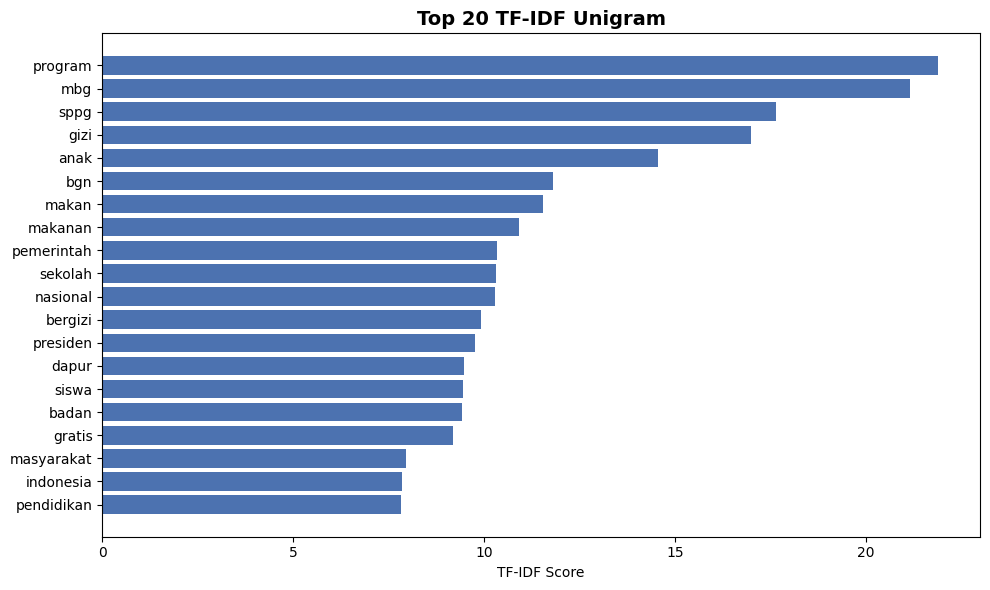

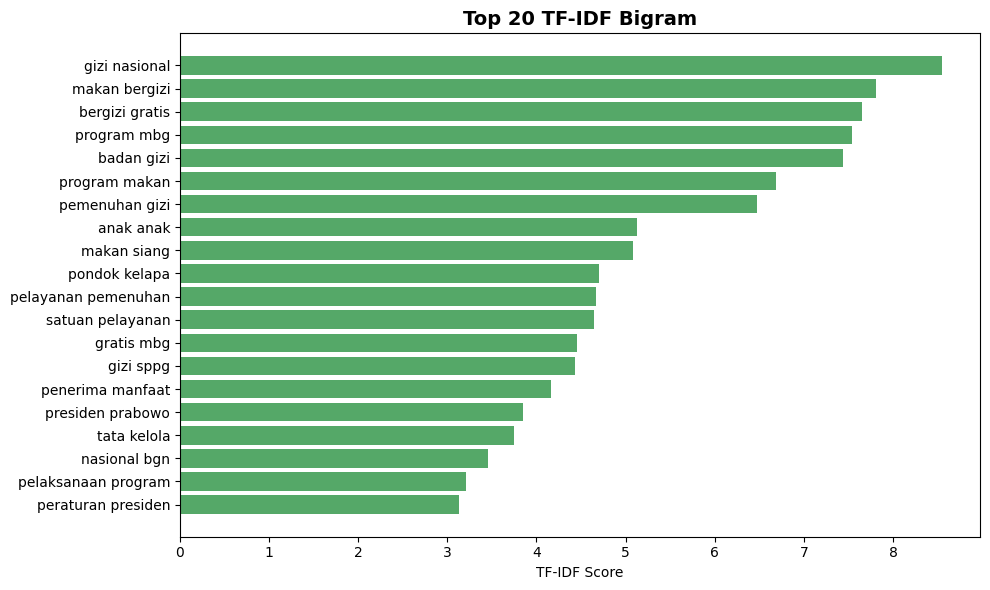

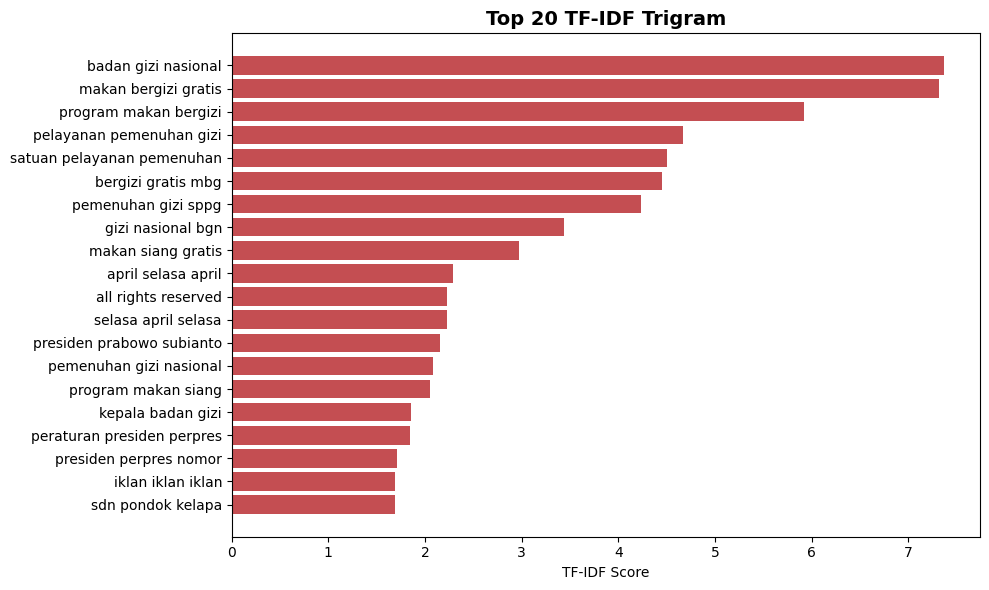

In [12]:
def plot_tfidf(df_top, title, color):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_top['ngram'].values[::-1], df_top['tfidf_score'].values[::-1], color=color)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    plt.tight_layout()
    plt.show()

plot_tfidf(top_tfidf_uni, f'Top {TOP_N} TF-IDF Unigram', '#4C72B0')
plot_tfidf(top_tfidf_bi,  f'Top {TOP_N} TF-IDF Bigram',  '#55A868')
plot_tfidf(top_tfidf_tri, f'Top {TOP_N} TF-IDF Trigram', '#C44E52')


## 7. Simpan Hasil ke CSV

In [9]:
pd.DataFrame([((' '.join(g)), f) for g, f in unigram_freq.most_common()],
             columns=['unigram', 'frekuensi']).to_csv('ngram_unigram.csv', index=False)

pd.DataFrame([((' '.join(g)), f) for g, f in bigram_freq.most_common()],
             columns=['bigram', 'frekuensi']).to_csv('ngram_bigram.csv', index=False)

pd.DataFrame([((' '.join(g)), f) for g, f in trigram_freq.most_common()],
             columns=['trigram', 'frekuensi']).to_csv('ngram_trigram.csv', index=False)

print('Hasil disimpan ke ngram_unigram.csv, ngram_bigram.csv, ngram_trigram.csv')

Hasil disimpan ke ngram_unigram.csv, ngram_bigram.csv, ngram_trigram.csv
